In [ ]:
# first, let's get the RSSAC002 data (thanks Duane Wessels)

!git clone git@github.com:rssac-caucus/RSSAC002-data.git

In [4]:
#some imports
import yaml
import glob
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import datetime as dt
import os

# =========================
# Typography / LaTeX
# =========================
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 13,
    "pdf.fonttype": 42,
    "ps.useafm": True,
    "pdf.use14corefonts": True,
    "figure.autolayout": True,
})



In [45]:
import glob
import yaml
import pandas as pd

# let's only get 2025 and 2026
files = glob.glob('RSSAC002-data/2025/*/rcode-volume/*') + \
        glob.glob('RSSAC002-data/2026/*/rcode-volume/*')

rows = []
for k in files:
    with open(k, 'r') as f:
        data = yaml.safe_load(f)
        service = data['service'].split("-")[0].replace(".", "").upper()
      
        date = str(data['start-period']).split("T")[0].split(" ")[0]
        #print(date)
        if '7' in data:
            rcode7 = int(data['7'])
            rows.append({'service': service, 'date': date, 'rcode7': rcode7})
        elif 7 in data:
            rcode7 = int(data[7])
            rows.append({'service': service, 'date': date, 'rcode7': rcode7})
df = pd.DataFrame(rows)

df['date'] = pd.to_datetime(df['date'])   # -> datetime64[ns]

print(df)
print(df.dtypes)

     service       date  rcode7
0      JROOT 2025-08-11       4
1      MROOT 2025-08-27       2
2      MROOT 2025-08-17       5
3      AROOT 2025-08-21     299
4      EROOT 2025-08-30       2
...      ...        ...     ...
2709   MROOT 2026-06-19       2
2710   AROOT 2026-06-20     100
2711   LROOT 2026-06-07       3
2712   MROOT 2026-06-01       4
2713   JROOT 2026-06-08       5

[2714 rows x 3 columns]
service            object
date       datetime64[ns]
rcode7              int64
dtype: object


In [48]:
df = df.sort_values("date").reset_index(drop=True)


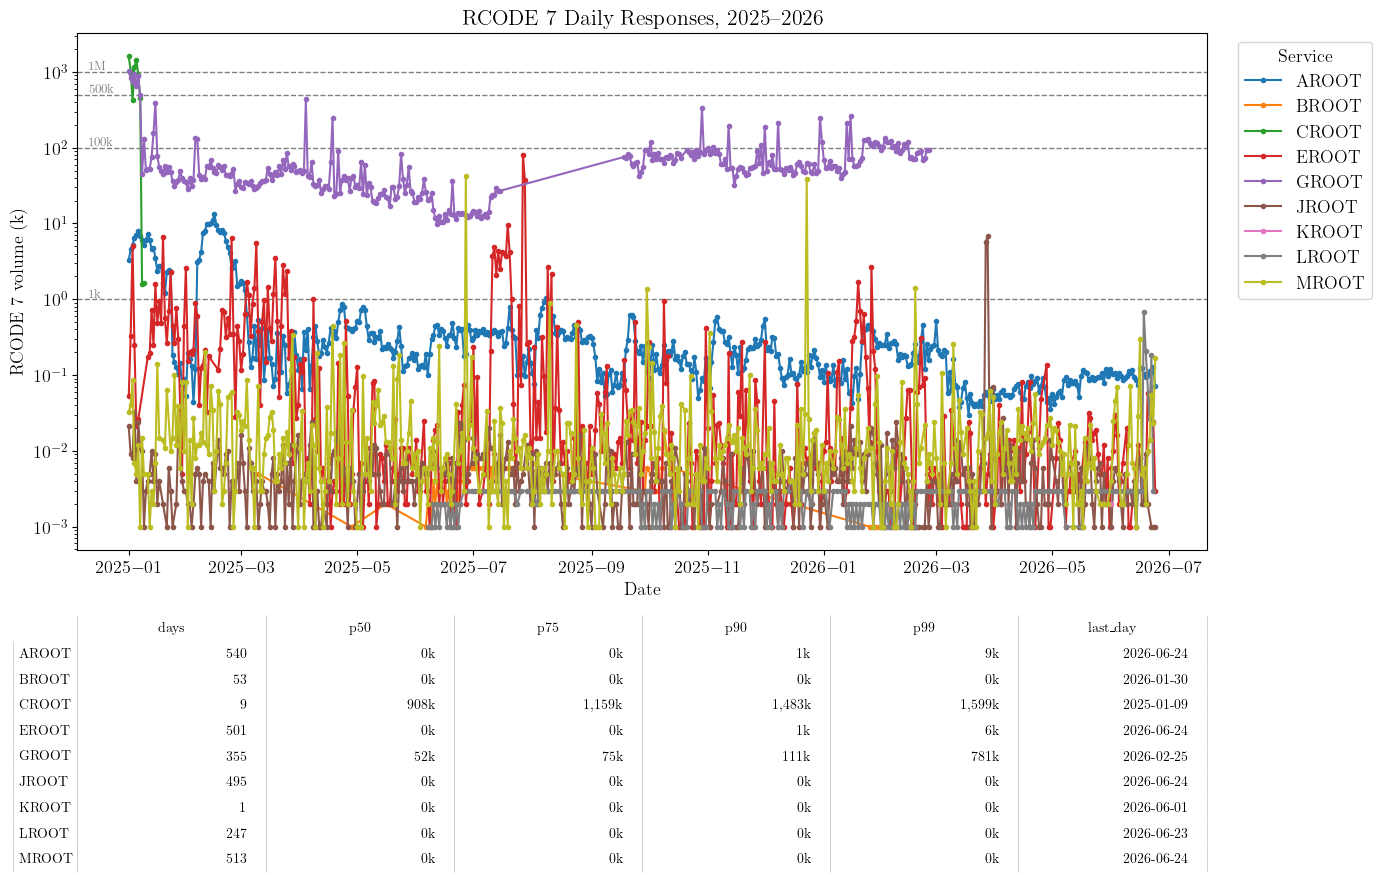

In [62]:
import matplotlib.pyplot as plt

SCALE = 1e3
df = df.sort_values('date')

def pct(n):
    f = lambda x: x.quantile(n / 100)
    f.__name__ = f'p{n}'
    return f

# percentiles + day count
dist = (df.groupby('service')['rcode7']
          .agg(days='count',
               p50=pct(50), p75=pct(75), p90=pct(90), p99=pct(99))
          .sort_index())

# last date rcode7 was present (non-null). Use `df[df['rcode7'] > 0]` for non-zero.
last_day = df.groupby('service')['date'].max()
dist['last_day'] = last_day

def fmt_row(row):
    days = f'{int(row["days"]):,}'
    vals = [f'{row[c]/1e3:,.0f}k' for c in ['p50', 'p75', 'p90', 'p99']]
    last = pd.to_datetime(row['last_day']).strftime('%Y-%m-%d')
    return [days] + vals + [last]

cell_text = [fmt_row(row) for _, row in dist.iterrows()]
col_labels = ['days', 'p50', 'p75', 'p90', 'p99', 'last_day']

fig, (ax, ax_tbl) = plt.subplots(
    2, 1, figsize=(14, 9),
    gridspec_kw={'height_ratios': [4, 1]}
)

for service, grp in df.groupby('service'):
    ax.plot(grp['date'], grp['rcode7']/SCALE, marker='.', label=service)

ax.set_yscale('log')

ref_lines = {'1k': 1_000, '100k': 100_000, '500k': 500_000, '1M': 1_000_000}
for label, raw in ref_lines.items():
    y = raw / SCALE
    ax.axhline(y, color='gray', linestyle='--', linewidth=1, zorder=0)
    ax.text(0.01, y, label, transform=ax.get_yaxis_transform(),
            va='bottom', ha='left', color='gray', fontsize=9)

ax.set_xlabel('Date')
ax.set_ylabel('RCODE 7 volume (k)')
ax.set_title('RCODE 7 Daily Responses, 2025–2026')
ax.legend(title='Service', bbox_to_anchor=(1.02, 1), loc='upper left')

ax_tbl.axis('off')
tbl = ax_tbl.table(
    cellText=cell_text,
    rowLabels=dist.index,
    colLabels=col_labels,
    cellLoc='right',
    rowLoc='left',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)

for (r, c), cell in tbl.get_celld().items():
    cell.visible_edges = 'LR'
    cell.set_edgecolor('#cccccc')
    cell.set_linewidth(0.6)
    cell.set_text_props(fontweight='bold')

plt.show()